# ARMA, ARIMA, SARIMA


## Упражнение

- Посмотрите на данные датчика, который отслеживает атмосферный CO2 из непрерывных проб воздуха в обсерватории Мауна-Лоа на Гавайях. Эти данные включают пробы CO2 с марта 1958 года по декабрь 1980 года.

In [2]:
import pandas as pd
co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1',
                  header = 0,
                  names = ['idx', 'co2'],
                  skipfooter = 2)

# convert the column idx into a datetime object and set it as the index
co2['idx'] = pd.to_datetime(co2['idx'])
co2.set_index('idx', inplace=True)

# Rmove the name "idx" from the index column
co2.index.name = None
co2

/tmp/ipykernel_32608/1895659819.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1',


,co2
1965-01-01,319.32
1965-02-01,320.36
1965-03-01,320.82
1965-04-01,322.06
1965-05-01,322.17
...,...
1980-08-01,337.19
1980-09-01,335.49
1980-10-01,336.63
1980-11-01,337.74


- Определите наличие основного тренда и сезонности в данных.
- Определите, являются ли данные стационарными.
- Разделите данные на обучающие (90%) и тестовые (10%).
- Найдите набор моделей-кандидатов SARIMAX, посмотрев на ACF и PACF.
- Выполните поиск по сетке для моделей-кандидатов.
- Выберите лучшие модели на основе показателей производительности, сложности модели и нормальности остатков.
- Сравните лучшую найденную вами модель с моделью из autoarima.

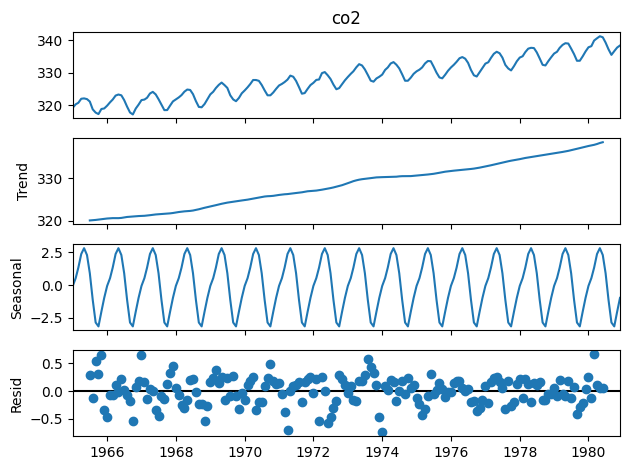

статистика теста: 1.2696771490032224
p-value: 0.9964336403294772
ряд не стационарный


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# 1. визуальный анализ
decomposition = seasonal_decompose(co2['co2'], model='additive', period=12)
decomposition.plot()
plt.show()

# 2. тест на стационарность (адф тест)
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print(f'статистика теста: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print('ряд стационарный')
    else:
        print('ряд не стационарный')

check_stationarity(co2['co2'])

есть тренд и сезонность

In [ ]:
import pandas as pd
import numpy as np
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')

# загрузка и базовая подготовка
co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1',
                  header = 0, names = ['idx', 'co2'], skipfooter = 2)
co2['idx'] = pd.to_datetime(co2['idx'])
co2.set_index('idx', inplace=True)
co2.index.name = None

# разделение данных 90 на 10
train_size = int(len(co2) * 0.9)
train, test = co2.iloc[:train_size], co2.iloc[train_size:]

# поиск по сетке для саримакс
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

best_aic = float("inf")
best_pdq = None
best_seasonal = None
best_model = None

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            temp_model = SARIMAX(train, order=param, seasonal_order=param_seasonal)
            results = temp_model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_pdq = param
                best_seasonal = param_seasonal
                best_model = results
        except:
            continue

# прогноз лучшей моделью
forecast_manual = best_model.get_forecast(steps=len(test)).predicted_mean

# сравнение с автоаримой
model_auto = auto_arima(train, seasonal=True, m=12, suppress_warnings=True)
forecast_auto = model_auto.predict(n_periods=len(test))

print(f"лучшие параметры вручную: {best_pdq} x {best_seasonal}")
print(f"aic ручной модели: {best_model.aic}")
print(f"aic автоаримы: {model_auto.aic()}")
print(f"rmse ручной: {np.sqrt(mean_squared_error(test, forecast_manual))}")
print(f"rmse авто: {np.sqrt(mean_squared_error(test, forecast_auto))}")

лучшие параметры вручную: (0, 1, 1) x (0, 1, 1, 12)
aic ручной модели: 90.47374747911148
aic автоаримы: 108.77043056346099
rmse ручной: 0.8174697971981743
rmse авто: 0.9568713619297992
